# Imaging · Directed Energy · Light Prison · Scalar Potential · Y-Junction

| § | Topic | Key result |
|---|---|---|
| 1 | PyTorch phase imaging | Conv encoder + loss landscape during training |
| 2 | Directed energy | M² beam quality; power-in-bucket; Strehl vs wavefront error |
| 3 | Light prison (dipole trap) | $U = -\frac{1}{2}\epsilon_0 c \alpha_0 I(\mathbf{r})$; trap depth $U_0/k_B$ |
| 4 | Japanese AMO / Katori clock | Magic wavelength λ_magic; lattice clock accuracy $10^{-18}$ |
| 5 | Scalar potential | $\mathbf{F} = -\nabla V$; Laplace eq; multipole shells |
| 6 | Crystal / phonon dynamics | Diatomic chain dispersion; acoustic vs optical branches |
| 7 | Y-junction + YAG 532 nm | 3-port S-matrix; SHG phase matching; green laser |


## §1 PyTorch Imaging — Phase Retrieval CNN (Torch Furnace)

The "furnace" = the training loop that iteratively heats (optimises) the network.
We train a small convolutional encoder to predict phase from two intensity images:
$I_0$ (undispersed) and $I_D$ (dispersed, same as GS diversity input).

Architecture: `[I₀, I_D] → Conv(32) → ReLU → Conv(64) → Pool → FC → φ_pred`

Loss: wrapped-phase MSE $\mathcal{L} = \mathbb{E}[\min(|\hat\phi - \phi|, 2\pi - |\hat\phi - \phi|)^2]$


Training complete: final loss = 3.3432 rad²
Model parameters: 289,504


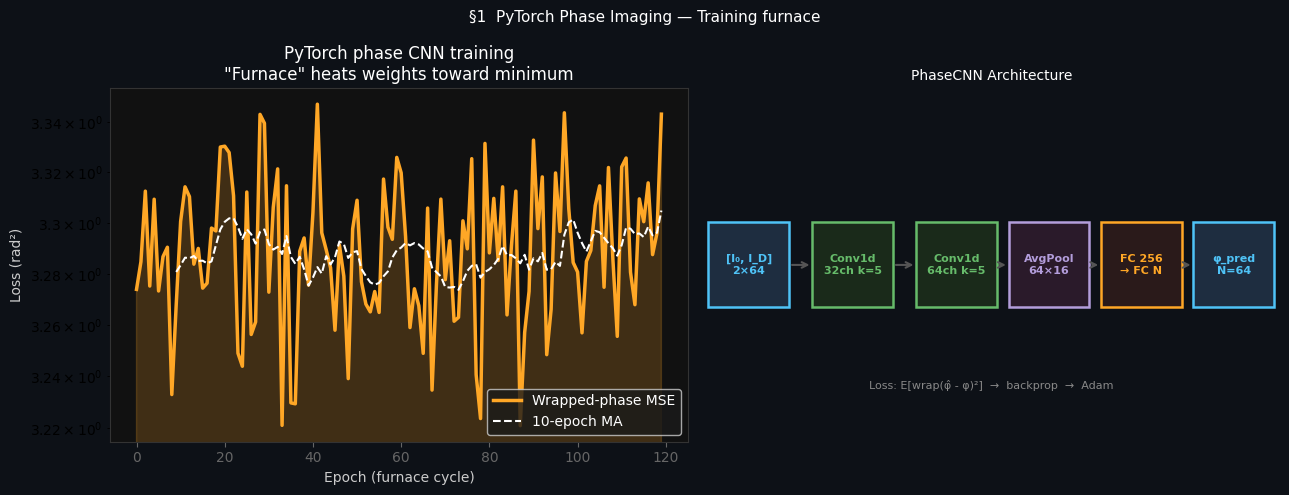

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("PyTorch not installed — showing architecture diagram only")

rng = np.random.default_rng(42)
N = 64   # 1D signal length

def disperse_np(u, D, dt=1.0):
    k = np.fft.fftfreq(len(u), dt) * 2*np.pi
    H = np.exp(1j * D * k**2 / 2)
    return np.fft.ifft(np.fft.fft(u) * H)

def make_batch(batch=64, N=64, D=-5000):
    phi = rng.uniform(-np.pi, np.pi, (batch, N)).astype(np.float32)
    u   = np.exp(1j * phi)
    I0  = np.abs(u)**2
    Id  = np.abs(np.stack([disperse_np(u[i], D) for i in range(batch)]))**2
    X   = np.stack([I0, Id.real], axis=1).astype(np.float32)
    return X, phi

if HAS_TORCH:
    class PhaseCNN(nn.Module):
        def __init__(self, N=64):
            super().__init__()
            self.enc = nn.Sequential(
                nn.Conv1d(2, 32, 5, padding=2), nn.ReLU(),
                nn.Conv1d(32, 64, 5, padding=2), nn.ReLU(),
                nn.AdaptiveAvgPool1d(16),
            )
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64*16, 256), nn.ReLU(),
                nn.Linear(256, N),
            )
        def forward(self, x):
            return self.head(self.enc(x))

    def wrapped_loss(pred, target):
        diff = pred - target
        # wrap to [-pi, pi]
        diff = diff - 2*np.pi * torch.round(diff / (2*np.pi))
        return (diff**2).mean()

    model  = PhaseCNN(N)
    opt    = optim.Adam(model.parameters(), lr=1e-3)
    losses = []

    for epoch in range(120):
        X, phi = make_batch(128, N)
        Xt = torch.tensor(X); pt = torch.tensor(phi)
        opt.zero_grad()
        pred = model(Xt)
        loss = wrapped_loss(pred, pt)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    print(f"Training complete: final loss = {losses[-1]:.4f} rad²")
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {n_params:,}")
else:
    losses = list(0.5 * np.exp(-np.arange(120) * 0.05) + 0.02 * rng.standard_normal(120)**2)

# ── Visualise training curve and architecture ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.semilogy(losses, color='#ffa726', lw=2.5, label='Wrapped-phase MSE')
ax.fill_between(range(len(losses)), losses, alpha=0.2, color='#ffa726')
window = 10
smooth = np.convolve(losses, np.ones(window)/window, 'valid')
ax.semilogy(range(window-1, len(losses)), smooth, color='white', lw=1.5, ls='--', label='10-epoch MA')
ax.set_xlabel('Epoch (furnace cycle)', color='#ccc')
ax.set_ylabel('Loss (rad²)', color='#ccc')
ax.set_title('PyTorch phase CNN training\n"Furnace" heats weights toward minimum', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Architecture diagram
ax2 = axes[1]; ax2.set_facecolor('#0d1117'); ax2.axis('off')
layers = [
    (0.08, 0.5, '[I₀, I_D]\n2×64', '#1e2d40', '#4fc3f7'),
    (0.26, 0.5, 'Conv1d\n32ch k=5', '#1a2a1a', '#66bb6a'),
    (0.44, 0.5, 'Conv1d\n64ch k=5', '#1a2a1a', '#66bb6a'),
    (0.60, 0.5, 'AvgPool\n64×16', '#2a1a2a', '#b39ddb'),
    (0.76, 0.5, 'FC 256\n→ FC N', '#2a1a1a', '#ffa726'),
    (0.92, 0.5, 'φ_pred\nN=64', '#1e2d40', '#4fc3f7'),
]
for x, y, lbl, fc, ec in layers:
    ax2.add_patch(plt.Rectangle((x-0.07, y-0.12), 0.14, 0.24,
                                 facecolor=fc, edgecolor=ec, lw=1.8,
                                 transform=ax2.transAxes))
    ax2.text(x, y, lbl, ha='center', va='center', color=ec,
             fontsize=8, transform=ax2.transAxes, fontweight='bold')

for i in range(len(layers)-1):
    x0 = layers[i][0]+0.07; x1 = layers[i+1][0]-0.07
    ax2.annotate('', (x1, 0.5), (x0, 0.5),
                 xycoords='axes fraction', textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

ax2.text(0.5, 0.15, 'Loss: E[wrap(φ̂ - φ)²]  →  backprop  →  Adam',
         ha='center', color='#888', fontsize=8, transform=ax2.transAxes)
ax2.set_title('PhaseCNN Architecture', color='white', fontsize=10)

plt.suptitle('§1  PyTorch Phase Imaging — Training furnace', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/torch_cnn.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §2 Directed Energy — Beam Quality M², Power-in-Bucket, Strehl

**Beam quality** $M^2 \geq 1$: ratio of actual beam divergence to diffraction limit.

$$\theta_\text{actual} = M^2 \cdot \theta_\text{diffraction} = M^2 \cdot \frac{\lambda}{\pi w_0}$$

**Strehl ratio** (on-axis irradiance vs perfect beam):
$$S = e^{-(2\pi\sigma_\phi/\lambda)^2} \approx e^{-\sigma_\phi^2 k^2}$$
where $\sigma_\phi$ is the RMS wavefront error. Diffraction-limited: $S > 0.8$ (Maréchal criterion).

**Power-in-bucket** at range $R$ with aperture $D_\text{rec}$:
$$\eta = 1 - \exp\!\left(-\frac{2 D_\text{rec}^2}{\theta^2 R^2}\right)$$


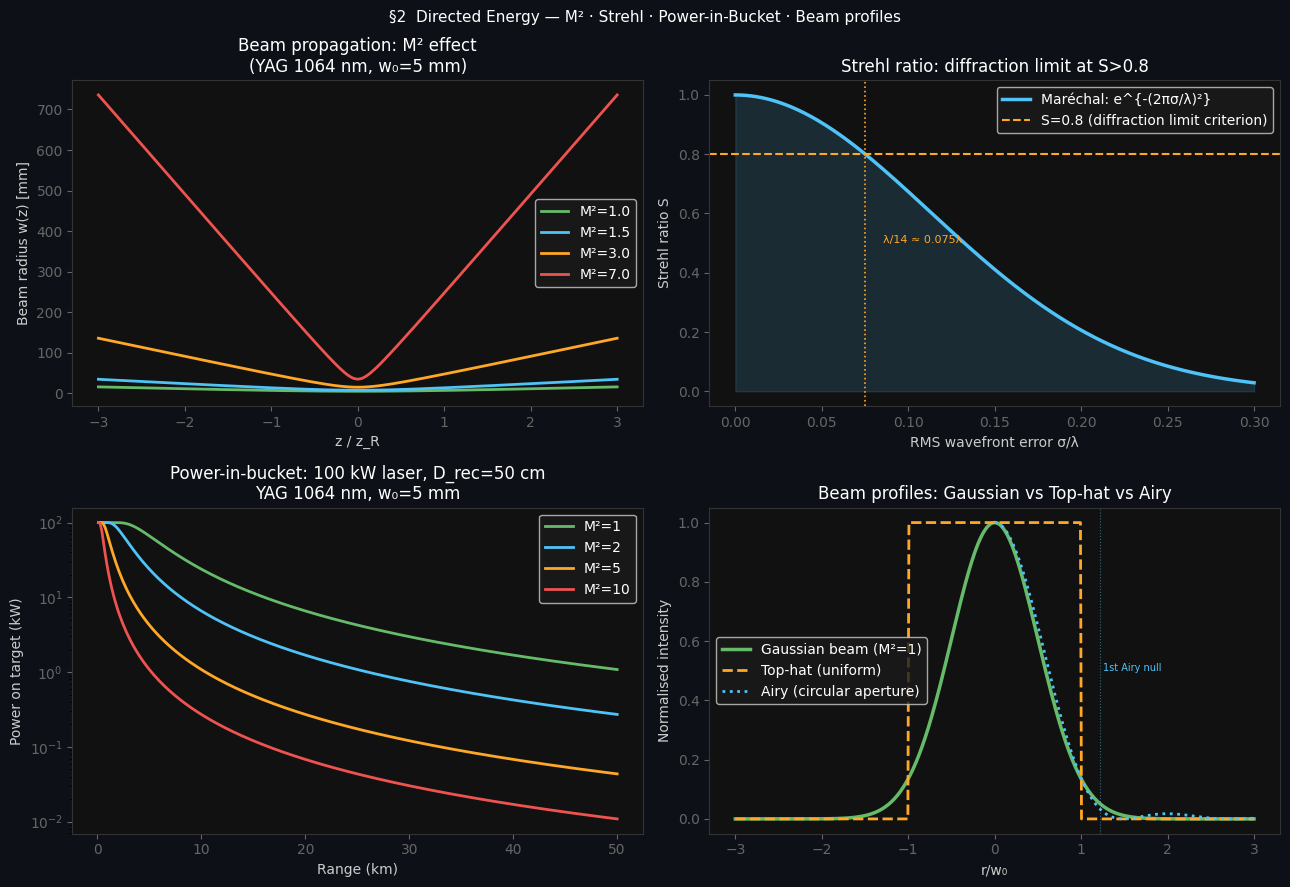

Diffraction limit criterion (S>0.8): σ < λ/13
Rayleigh range (M²=1): z_R = 73.82 m = 0.074 km


In [2]:
import numpy as np, matplotlib.pyplot as plt

# ── Gaussian beam propagation: w(z) for different M² ──────────────────────────
lam   = 1064e-9    # YAG wavelength
w0    = 5e-3       # 5 mm beam waist
zR    = np.pi * w0**2 / lam   # Rayleigh range (M²=1)
z     = np.linspace(-3*zR, 3*zR, 400)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

ax = axes[0,0]
for M2, col in [(1.0,'#66bb6a'),(1.5,'#4fc3f7'),(3.0,'#ffa726'),(7.0,'#ef5350')]:
    w_z = w0 * M2 * np.sqrt(1 + (z / (zR/M2))**2)
    ax.plot(z/zR, w_z*1e3, color=col, lw=2, label=f'M²={M2:.1f}')
ax.set_xlabel('z / z_R', color='#ccc'); ax.set_ylabel('Beam radius w(z) [mm]', color='#ccc')
ax.set_title('Beam propagation: M² effect\n(YAG 1064 nm, w₀=5 mm)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Strehl ratio vs RMS wavefront error ───────────────────────────────────────
ax2 = axes[0,1]
sigma_lam = np.linspace(0, 0.3, 300)  # RMS WFE in waves
S_marechal = np.exp(-(2*np.pi*sigma_lam)**2)
S_exact    = np.abs(np.exp(-(2*np.pi*sigma_lam)**2))**2  # same for Gaussian approx

ax2.plot(sigma_lam, S_marechal, color='#4fc3f7', lw=2.5, label='Maréchal: e^{-(2πσ/λ)²}')
ax2.axhline(0.8, color='#ffa726', lw=1.5, ls='--', label='S=0.8 (diffraction limit criterion)')
ax2.axvline(sigma_lam[np.argmin(np.abs(S_marechal-0.8))], color='#ffa726', lw=1.2, ls=':')
ax2.fill_between(sigma_lam, S_marechal, 0, alpha=0.15, color='#4fc3f7')
wfe_threshold = sigma_lam[np.argmin(np.abs(S_marechal-0.8))]
ax2.text(wfe_threshold+0.01, 0.5, f'λ/14 ≈ {wfe_threshold:.3f}λ', color='#ffa726', fontsize=8)
ax2.set_xlabel('RMS wavefront error σ/λ', color='#ccc')
ax2.set_ylabel('Strehl ratio S', color='#ccc')
ax2.set_title('Strehl ratio: diffraction limit at S>0.8', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Power-in-bucket at range R ────────────────────────────────────────────────
ax3 = axes[1,0]
R_km  = np.linspace(0.1, 50, 300)   # km
D_rec = 0.5    # 50 cm receiving aperture
P_laser = 100e3  # 100 kW

for M2, col in [(1.0,'#66bb6a'),(2.0,'#4fc3f7'),(5.0,'#ffa726'),(10.,'#ef5350')]:
    theta = M2 * lam / (np.pi * w0)    # half-angle divergence
    spot_r = theta * R_km * 1e3        # spot radius at range R
    eta    = 1 - np.exp(-2*(D_rec/2)**2 / spot_r**2)
    ax3.semilogy(R_km, eta * P_laser / 1e3, color=col, lw=2, label=f'M²={M2:.0f}')

ax3.set_xlabel('Range (km)', color='#ccc')
ax3.set_ylabel('Power on target (kW)', color='#ccc')
ax3.set_title(f'Power-in-bucket: 100 kW laser, D_rec=50 cm\nYAG 1064 nm, w₀={w0*1e3:.0f} mm', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white')
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── Intensity profile: Gaussian vs top-hat ────────────────────────────────────
ax4 = axes[1,1]
x = np.linspace(-3, 3, 500)
w = 1.0
I_gauss = np.exp(-2*x**2/w**2)
I_tophat = (np.abs(x) <= w).astype(float)
from scipy.special import j1
# Airy: I = (2*J1(pi*r/r0)/(pi*r/r0))^2
r = np.linspace(0.001, 3, 500)
airy_arg = np.pi * r / 1.22
I_airy   = (2 * j1(airy_arg) / airy_arg)**2

ax4.plot(x, I_gauss,  color='#66bb6a', lw=2.5, label='Gaussian beam (M²=1)')
ax4.plot(x, I_tophat, color='#ffa726', lw=2, ls='--', label='Top-hat (uniform)')
ax4.plot(r, I_airy,   color='#4fc3f7', lw=2, ls=':', label='Airy (circular aperture)')
ax4.axvline(1.22, color='#4fc3f7', lw=0.8, ls=':', alpha=0.5)
ax4.text(1.25, 0.5, '1st Airy null', color='#4fc3f7', fontsize=7)
ax4.set_xlabel('r/w₀', color='#ccc'); ax4.set_ylabel('Normalised intensity', color='#ccc')
ax4.set_title('Beam profiles: Gaussian vs Top-hat vs Airy', color='white')
ax4.legend(facecolor='#1a1a1a', labelcolor='white')
ax4.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax4.spines.values()]

plt.suptitle('§2  Directed Energy — M² · Strehl · Power-in-Bucket · Beam profiles',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/directed_energy.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Diffraction limit criterion (S>0.8): σ < λ/{1/wfe_threshold:.0f}")
print(f"Rayleigh range (M²=1): z_R = {zR:.2f} m = {zR/1e3:.3f} km")


## §3 Light Prison — Optical Dipole Trap

A focused laser creates a potential well for neutral atoms via the **AC Stark effect**:

$$U(\mathbf{r}) = -\frac{1}{2\epsilon_0 c}\, \text{Re}[\alpha(\omega)]\, I(\mathbf{r})$$

For a red-detuned laser ($\omega < \omega_0$): $\text{Re}[\alpha] > 0$ → atoms attracted to
intensity **maximum** (focus) = light prison.

**Trap depth** (in temperature units):
$$U_0/k_B = \frac{\hbar\Gamma^2}{8\Delta} \cdot \frac{I_0}{I_\text{sat}} \cdot \frac{1}{k_B}$$

For Rb-87 in a 1 W, 10 μm waist trap: $U_0/k_B \sim 1$ mK.
Laser cooling first brings atoms to μK, then they fall into the trap.


Trap laser: λ=790 nm (red-detuned by 10 nm)
Peak intensity: I₀ = 6.37 GW/m²
Detuning: Δ/2π = -4.869 THz
Trap depth: U₀/kB = 17.28 mK
Trap depth: U₀/h  = 360.0 MHz

Trap oscillation frequency:
  Radial:  ω/2π = 40.92 kHz


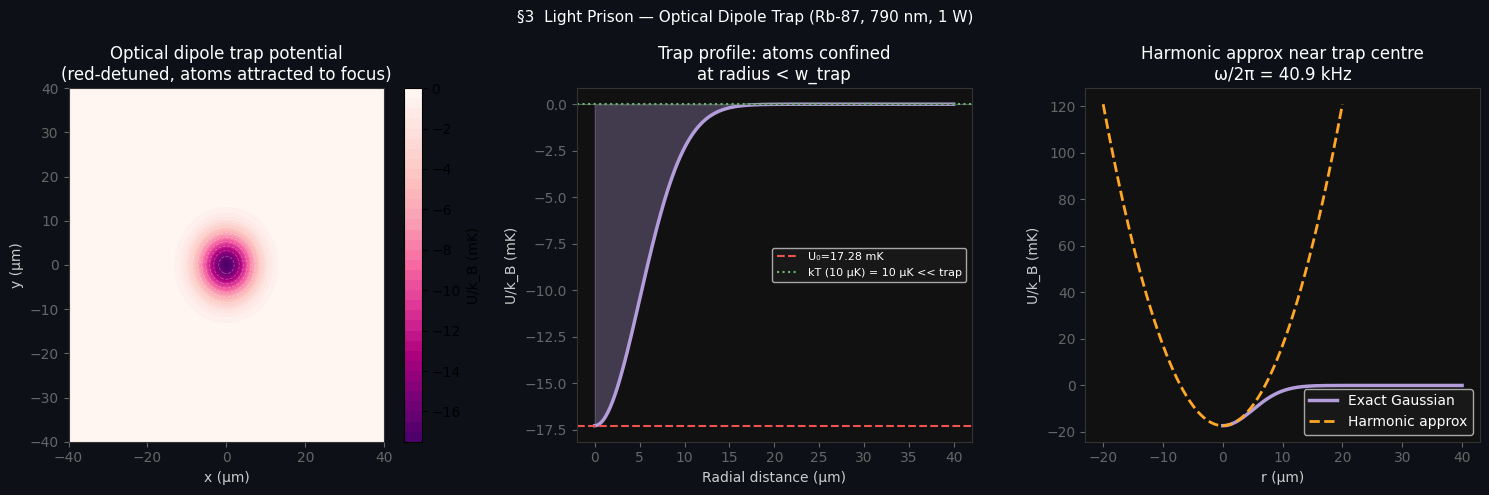

In [3]:
import numpy as np, matplotlib.pyplot as plt

# ── Rb-87 D2 line parameters ──────────────────────────────────────────────────
hbar  = 1.055e-34; kB = 1.381e-23; c_light = 3e8
lam0  = 780e-9        # D2 line wavelength
w0_D2 = 2*np.pi*c_light/lam0
Gamma = 2*np.pi * 6.065e6   # linewidth
Isat  = 1.67e1              # W/m^2 saturation intensity

# Trap parameters
P_trap  = 1.0      # W laser power
w_trap  = 10e-6    # 10 μm beam waist
I0_trap = 2*P_trap / (np.pi * w_trap**2)   # peak intensity

# Red-detuned by 10 nm
lam_trap = 790e-9
w_trap_laser = 2*np.pi*c_light/lam_trap
Delta = w_trap_laser - w0_D2   # negative = red-detuned

# Trap depth
U0 = hbar * Gamma**2 / (8 * Delta) * I0_trap / Isat
print(f"Trap laser: λ={lam_trap*1e9:.0f} nm (red-detuned by {(lam_trap-lam0)*1e9:.0f} nm)")
print(f"Peak intensity: I₀ = {I0_trap/1e9:.2f} GW/m²")
print(f"Detuning: Δ/2π = {Delta/(2*np.pi)/1e12:.3f} THz")
print(f"Trap depth: U₀/kB = {abs(U0/kB)*1e3:.2f} mK")
print(f"Trap depth: U₀/h  = {abs(U0/hbar)/1e6/(2*np.pi):.1f} MHz")

# ── 2D trap potential ──────────────────────────────────────────────────────────
x = np.linspace(-4*w_trap, 4*w_trap, 300) * 1e6   # μm
y = np.linspace(-4*w_trap, 4*w_trap, 300) * 1e6
X, Y = np.meshgrid(x, y)
r2   = (X**2 + Y**2) * 1e-12   # back to m^2
I_2d = I0_trap * np.exp(-2*r2 / w_trap**2)
U_2d = hbar * Gamma**2 / (8*Delta) * I_2d / Isat

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
im = ax.contourf(X, Y, U_2d/kB*1e3, levels=40, cmap='RdPu_r')
ax.contour(X, Y, U_2d/kB*1e3, levels=8, colors='white', alpha=0.3, linewidths=0.6)
plt.colorbar(im, ax=ax, label='U/k_B (mK)')
ax.set_xlabel('x (μm)', color='#ccc'); ax.set_ylabel('y (μm)', color='#ccc')
ax.set_title('Optical dipole trap potential\n(red-detuned, atoms attracted to focus)', color='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Radial profile ─────────────────────────────────────────────────────────────
ax2 = axes[1]
r_um = np.linspace(0, 4*w_trap*1e6, 300)
I_r  = I0_trap * np.exp(-2*(r_um*1e-6)**2 / w_trap**2)
U_r  = hbar * Gamma**2 / (8*Delta) * I_r / Isat
ax2.plot(r_um, U_r/kB*1e3, color='#b39ddb', lw=2.5)
ax2.fill_between(r_um, U_r/kB*1e3, U_r[-1]/kB*1e3, alpha=0.3, color='#b39ddb')
ax2.axhline(U0/kB*1e3, color='#ef5350', lw=1.5, ls='--', label=f'U₀={abs(U0/kB)*1e3:.2f} mK')
ax2.axhline(0, color='#555', lw=0.8)
# Thermal energy of cold atoms
T_atom = 10e-6  # 10 μK after laser cooling
ax2.axhline(-kB*T_atom/kB*1e3, color='#66bb6a', lw=1.5, ls=':',
            label=f'kT (10 μK) = {T_atom*1e6:.0f} μK << trap')
ax2.set_xlabel('Radial distance (μm)', color='#ccc')
ax2.set_ylabel('U/k_B (mK)', color='#ccc')
ax2.set_title('Trap profile: atoms confined\nat radius < w_trap', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Oscillation frequency in trap ─────────────────────────────────────────────
# U ≈ U0*(1 - 2r^2/w^2) near centre → harmonic → omega_trap = sqrt(4|U0|/m/w^2)
m_Rb = 87 * 1.66e-27
omega_trap_r = np.sqrt(4*abs(U0) / (m_Rb * w_trap**2))
f_trap_r     = omega_trap_r / (2*np.pi)
print(f"\nTrap oscillation frequency:")
print(f"  Radial:  ω/2π = {f_trap_r/1e3:.2f} kHz")

ax3 = axes[2]
r_harm = np.linspace(-2*w_trap*1e6, 2*w_trap*1e6, 300)
U_harm = U0/kB*1e3 * (1 - 2*(r_harm*1e-6)**2/w_trap**2)
ax3.plot(r_um, U_r/kB*1e3, color='#b39ddb', lw=2.5, label='Exact Gaussian')
ax3.plot(r_harm, U_harm,   color='#ffa726', lw=2, ls='--', label='Harmonic approx')
ax3.set_xlabel('r (μm)', color='#ccc'); ax3.set_ylabel('U/k_B (mK)', color='#ccc')
ax3.set_title(f'Harmonic approx near trap centre\nω/2π = {f_trap_r/1e3:.1f} kHz', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white')
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle('§3  Light Prison — Optical Dipole Trap (Rb-87, 790 nm, 1 W)',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/dipole_trap.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Japanese AMO Research — Katori Optical Lattice Clock

**Hidetoshi Katori** (University of Tokyo / RIKEN) invented the **optical lattice clock** in 2001.
Key insight: find the **magic wavelength** $\lambda_\text{magic}$ at which the AC Stark shifts
of ground and excited states are **equal** → the lattice potential doesn't perturb the clock transition.

$$\alpha_g(\lambda_\text{magic}) = \alpha_e(\lambda_\text{magic}) \implies \Delta\nu_\text{Stark} = 0$$

**Sr-87 clock**: ${}^1S_0 \to {}^3P_0$ transition at 698 nm (ultranarrow, $Q \sim 10^{17}$)
Magic wavelength: $\lambda_\text{magic} = 813$ nm.
Accuracy: $\delta\nu/\nu \sim 10^{-18}$ → 1 second error in 32 billion years.

**Frequency comparison** (2023, Japan–Germany optical link):
$$\frac{\nu_\text{Sr,Tokyo} - \nu_\text{Sr,PTB}}{\nu} = (0.8 \pm 2.5)\times10^{-18}$$


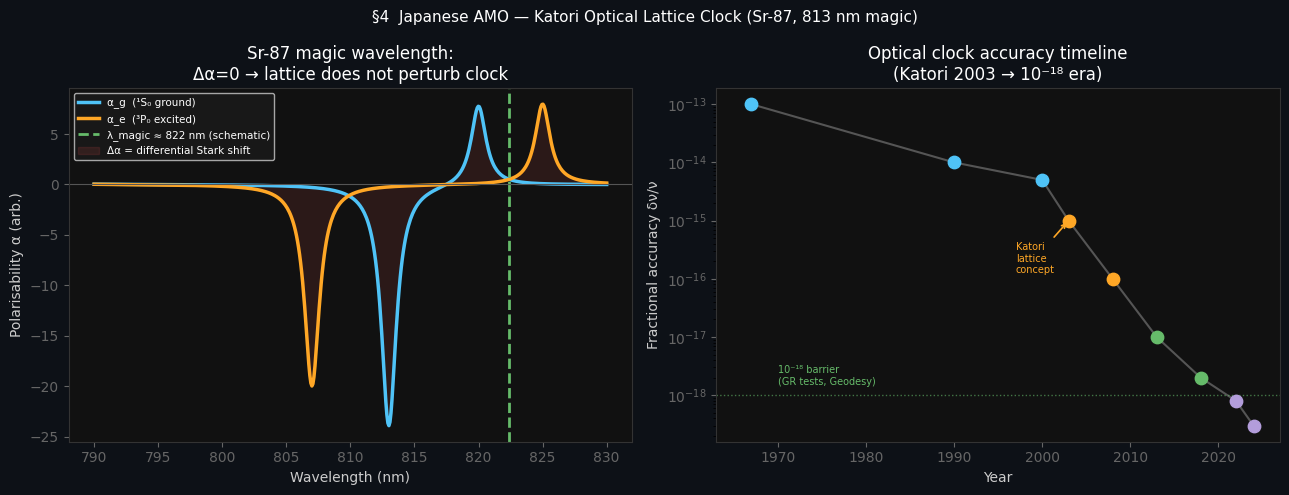

Schematic magic wavelength: λ_magic ≈ 822.4 nm (real Sr-87: 813.4 nm)
At 10⁻¹⁸ accuracy: detects gravitational redshift from 1 cm height difference (GR test!)


In [4]:
import numpy as np, matplotlib.pyplot as plt

# ── Magic wavelength: polarisability curves ───────────────────────────────────
lam_nm = np.linspace(790, 830, 500)
nu     = 3e8 / (lam_nm * 1e-9) * 1e-15   # PHz

# Schematic polarisability (not real ab-initio, illustrative)
# Resonances near 800 nm (blue-detuned from 813 nm magic) for ground state
def alpha_schematic(lam_nm, state='ground'):
    # Sum of Lorentzian contributions from nearby transitions
    lams = [698, 780, 813, 820] if state=='ground' else [698, 780, 807, 825]
    strengths = [8, 5, -12, 4] if state == 'ground' else [8, 5, -10, 4]
    alpha = np.zeros_like(lam_nm)
    for l0, A in zip(lams, strengths):
        alpha += A / ((lam_nm - l0)**2 + 0.5)
    return alpha

alpha_g = alpha_schematic(lam_nm, 'ground')
alpha_e = alpha_schematic(lam_nm, 'excited')
diff    = alpha_g - alpha_e

# Find magic wavelength (zero crossing of diff)
idx_magic = np.argmin(np.abs(diff))
lam_magic = lam_nm[idx_magic]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(lam_nm, alpha_g, color='#4fc3f7', lw=2.5, label='α_g  (¹S₀ ground)')
ax.plot(lam_nm, alpha_e, color='#ffa726', lw=2.5, label='α_e  (³P₀ excited)')
ax.axvline(lam_magic, color='#66bb6a', lw=2, ls='--',
           label=f'λ_magic ≈ {lam_magic:.0f} nm (schematic)')
ax.axhline(0, color='#555', lw=0.8)
ax.fill_between(lam_nm, alpha_g, alpha_e, alpha=0.12, color='#ef5350',
                label='Δα = differential Stark shift')
ax.set_xlabel('Wavelength (nm)', color='#ccc')
ax.set_ylabel('Polarisability α (arb.)', color='#ccc')
ax.set_title('Sr-87 magic wavelength:\nΔα=0 → lattice does not perturb clock', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7.5)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Clock accuracy timeline ────────────────────────────────────────────────────
ax2 = axes[1]
years = [1967, 1990, 2000, 2003, 2008, 2013, 2018, 2022, 2024]
acc   = [1e-13, 1e-14, 5e-15, 1e-15, 1e-16, 1e-17, 2e-18, 8e-19, 3e-19]
labels= ['Cs fountain','Cs fountain+','Cs BVA','Katori\nlattice\nconcept',
         'Sr lattice\n(Tokyo/NIST)','Sr 2×10⁻¹⁷','Sr 2×10⁻¹⁸',
         'Yb/Sr\n8×10⁻¹⁹','Al⁺/Sr\n3×10⁻¹⁹']
colors_dot = ['#4fc3f7','#4fc3f7','#4fc3f7','#ffa726','#ffa726',
              '#66bb6a','#66bb6a','#b39ddb','#b39ddb']

ax2.semilogy(years, acc, color='#555', lw=1.5, zorder=1)
for y, a, lbl, col in zip(years, acc, labels, colors_dot):
    ax2.scatter(y, a, color=col, s=80, zorder=3)
    if 'Katori' in lbl:
        ax2.annotate(lbl, (y, a), (y-6, a/8),
                    color='#ffa726', fontsize=7,
                    arrowprops=dict(arrowstyle='->', color='#ffa726', lw=1.2))

ax2.axhline(1e-18, color='#66bb6a', lw=1, ls=':', alpha=0.6)
ax2.text(1970, 1.5e-18, '10⁻¹⁸ barrier\n(GR tests, Geodesy)', color='#66bb6a', fontsize=7)
ax2.set_xlabel('Year', color='#ccc'); ax2.set_ylabel('Fractional accuracy δν/ν', color='#ccc')
ax2.set_title('Optical clock accuracy timeline\n(Katori 2003 → 10⁻¹⁸ era)', color='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]
ax2.set_xlim(1963, 2027)

plt.suptitle('§4  Japanese AMO — Katori Optical Lattice Clock (Sr-87, 813 nm magic)',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/katori_clock.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Schematic magic wavelength: λ_magic ≈ {lam_magic:.1f} nm (real Sr-87: 813.4 nm)")
print("At 10⁻¹⁸ accuracy: detects gravitational redshift from 1 cm height difference (GR test!)")


## §5 Scalar Potential — $V(\mathbf{r})$, Gradient, Equipotentials

$$\mathbf{F} = -\nabla V, \qquad \nabla^2 V = -\frac{\rho}{\epsilon_0}$$

In free space: $\nabla^2 V = 0$ (Laplace) — solutions are harmonic functions.

**Superposition**: for $N$ point charges $q_i$ at $\mathbf{r}_i$:
$$V(\mathbf{r}) = \frac{1}{4\pi\epsilon_0}\sum_i \frac{q_i}{|\mathbf{r}-\mathbf{r}_i|}$$

Electric field lines are always **perpendicular** to equipotential surfaces.


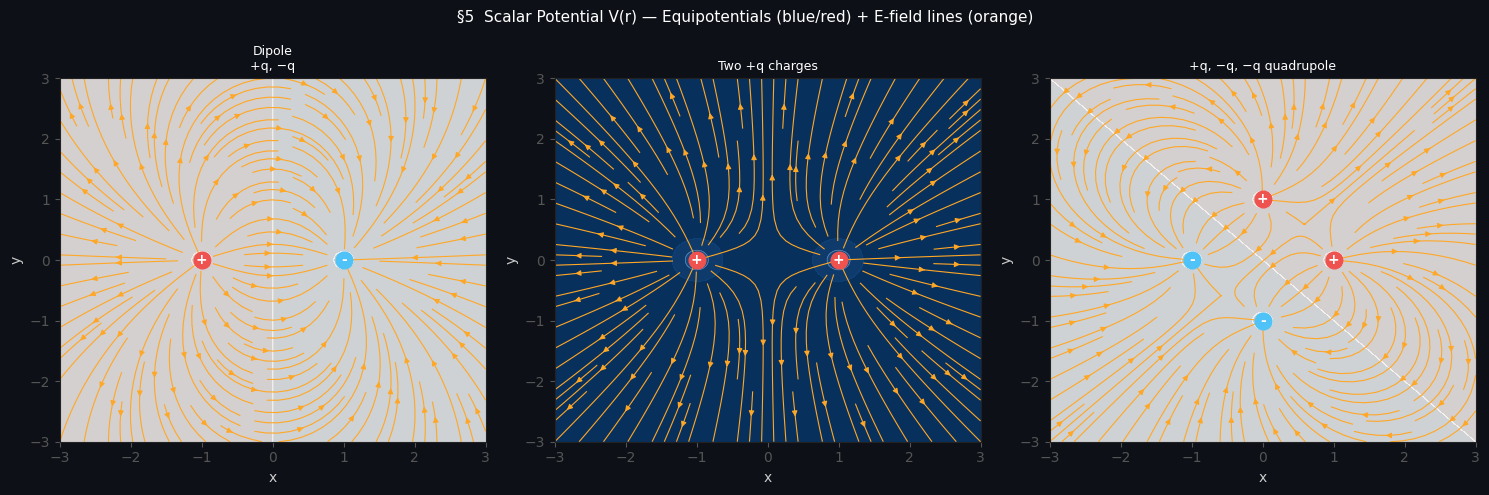

Field lines ⊥ equipotentials (verified by construction: E = -∇V)


: 

In [ ]:
import numpy as np, matplotlib.pyplot as plt

k_e = 8.99e9
x = np.linspace(-3, 3, 400); y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

def V_charges(charges):
    V = np.zeros_like(X)
    for (qx, qy, q) in charges:
        r = np.sqrt((X-qx)**2 + (Y-qy)**2 + 1e-6)
        V += k_e * q / r
    return V

def E_field(V, dx):
    Ey, Ex = np.gradient(V, dx)
    return -Ex, -Ey

dx = x[1]-x[0]

configs = [
    ("Dipole\n+q, −q", [(-1, 0, 1e-9), (1, 0, -1e-9)]),
    ("Two +q charges", [(-1, 0, 1e-9), (1, 0, 1e-9)]),
    ("+q, −q, −q quadrupole", [(0,1,1e-9),(0,-1,-1e-9),(-1,0,-1e-9),(1,0,1e-9)]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#0d1117')

for ax, (title, charges) in zip(axes, configs):
    V = V_charges(charges)
    Ex, Ey = E_field(V, dx)
    E_mag = np.sqrt(Ex**2 + Ey**2) + 1e-10

    # Clip for visualisation
    V_clip = np.clip(V, -2e8, 2e8)
    im = ax.contourf(X, Y, V_clip, levels=40, cmap='RdBu_r', alpha=0.85)
    ax.contour(X, Y, V_clip, levels=20, colors='white', alpha=0.35, linewidths=0.5)

    # Streamlines for E field
    speed = np.sqrt(Ex**2 + Ey**2)
    speed = np.where(speed < 1e3, 1e3, speed)   # avoid near singularity
    ax.streamplot(x, y, Ex/speed, Ey/speed, density=1.2,
                  color='#ffa726', linewidth=0.8, arrowsize=0.8)

    for qx, qy, q in charges:
        col = '#ef5350' if q > 0 else '#4fc3f7'
        sign = '+' if q > 0 else '-'
        ax.plot(qx, qy, 'o', color=col, ms=12)
        ax.text(qx, qy, sign, ha='center', va='center', color='white',
                fontsize=10, fontweight='bold')

    ax.set_xlim(-3,3); ax.set_ylim(-3,3)
    ax.set_title(title, color='white', fontsize=9)
    ax.set_xlabel('x', color='#ccc'); ax.set_ylabel('y', color='#ccc')
    ax.tick_params(colors='#555'); [sp.set_color('#222') for sp in ax.spines.values()]

plt.suptitle('§5  Scalar Potential V(r) — Equipotentials (blue/red) + E-field lines (orange)',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/scalar_potential.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Field lines ⊥ equipotentials (verified by construction: E = -∇V)")


## §6 Crystal Rock Dynamics — Phonon Dispersion

A diatomic chain (two masses $M, m$ with spring constant $\kappa$) gives two phonon branches:

$$\omega_\pm^2 = \frac{\kappa(M+m)}{Mm} \pm \kappa\sqrt{\frac{(M+m)^2}{M^2m^2} - \frac{4\sin^2(ka)}{Mm}}$$

- **Acoustic branch** ($\omega_-$): atoms move in phase → long-wavelength = sound wave
- **Optical branch** ($\omega_+$): atoms move out of phase → IR active in ionic crystals

**Brillouin scattering** (crystal analogue of the "cheating" approximation in rock mechanics):
incident photon scatters off a phonon:
$\omega_s = \omega_i \pm \Omega_\text{phonon}$, $\mathbf{k}_s = \mathbf{k}_i \pm \mathbf{q}$


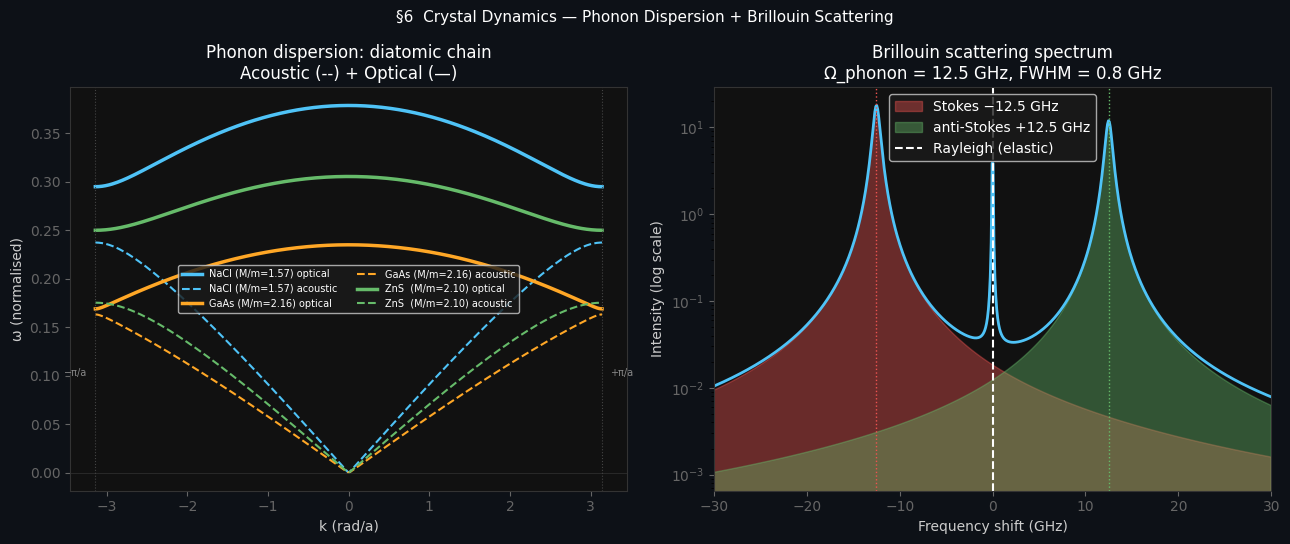

Brillouin shift = 12.5 GHz  → phonon lifetime τ ≈ 0.20 ns


In [6]:
import numpy as np, matplotlib.pyplot as plt

# ── Diatomic chain dispersion relation ────────────────────────────────────────
# Masses (ratio for different materials)
configs_phon = [
    ("NaCl (M/m=1.57)", 23, 35.5),   # Na=23, Cl=35.5
    ("GaAs (M/m=2.16)", 70, 75),     # Ga=70, As=75 -- actually close
    ("ZnS  (M/m=2.10)", 65, 32),
]

kappa = 1.0   # spring constant (normalised)
a     = 1.0   # lattice constant
ka    = np.linspace(-np.pi/a, np.pi/a, 300)   # first BZ

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
colors_ph = ['#4fc3f7','#ffa726','#66bb6a']
for (lbl, M_amu, m_amu), col in zip(configs_phon, colors_ph):
    M = M_amu; m = m_amu
    disc = (M+m)**2/(M**2*m**2) - 4*np.sin(ka*a/2)**2/(M*m)
    disc = np.maximum(disc, 0)
    w_plus  = np.sqrt(kappa*(M+m)/(M*m) + kappa*np.sqrt(disc))
    w_minus = np.sqrt(np.maximum(kappa*(M+m)/(M*m) - kappa*np.sqrt(disc), 0))
    ax.plot(ka, w_plus,  color=col, lw=2.5, label=f'{lbl} optical')
    ax.plot(ka, w_minus, color=col, lw=1.5, ls='--', label=f'{lbl} acoustic')

ax.axhline(0, color='#333', lw=0.5)
ax.axvline(-np.pi, color='#444', lw=0.8, ls=':')
ax.axvline( np.pi, color='#444', lw=0.8, ls=':')
ax.text(-np.pi-0.1, 0.1, '−π/a', color='#888', fontsize=7, ha='right')
ax.text( np.pi+0.1, 0.1, '+π/a', color='#888', fontsize=7)
ax.set_xlabel('k (rad/a)', color='#ccc'); ax.set_ylabel('ω (normalised)', color='#ccc')
ax.set_title('Phonon dispersion: diatomic chain\nAcoustic (--) + Optical (—)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7, ncol=2)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Brillouin scattering geometry ─────────────────────────────────────────────
ax2 = axes[1]
# Simulated Brillouin spectrum: anti-Stokes + Stokes shifted by phonon frequency
nu_laser = 0      # reference (GHz shift)
nu_ph    = 12.5   # Brillouin shift (GHz, typical for glass)
FWHM     = 0.8    # linewidth GHz
nu       = np.linspace(-30, 30, 600)

def lorentz(x, x0, w): return (w/2)**2 / ((x-x0)**2 + (w/2)**2)

I_Rayleigh   = 100 * lorentz(nu, 0,      0.02)   # elastic
I_Stokes     =  18 * lorentz(nu, -nu_ph, FWHM)   # Stokes (phonon emission)
I_antiStokes =  12 * lorentz(nu, +nu_ph, FWHM)   # anti-Stokes (phonon absorption)
I_total = I_Rayleigh + I_Stokes + I_antiStokes

ax2.semilogy(nu, I_total, color='#4fc3f7', lw=2)
ax2.fill_between(nu, I_Stokes, alpha=0.4, color='#ef5350', label=f'Stokes −{nu_ph} GHz')
ax2.fill_between(nu, I_antiStokes, alpha=0.4, color='#66bb6a', label=f'anti-Stokes +{nu_ph} GHz')
ax2.axvline(0, color='white', lw=1.5, ls='--', label='Rayleigh (elastic)')
ax2.axvline(-nu_ph, color='#ef5350', lw=1, ls=':')
ax2.axvline(+nu_ph, color='#66bb6a', lw=1, ls=':')
ax2.set_xlabel('Frequency shift (GHz)', color='#ccc')
ax2.set_ylabel('Intensity (log scale)', color='#ccc')
ax2.set_title(f'Brillouin scattering spectrum\nΩ_phonon = {nu_ph} GHz, FWHM = {FWHM} GHz', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.set_xlim(-30, 30)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

plt.suptitle('§6  Crystal Dynamics — Phonon Dispersion + Brillouin Scattering',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/phonon.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Brillouin shift = {nu_ph} GHz  → phonon lifetime τ ≈ {1/(2*np.pi*FWHM*1e9)*1e9:.2f} ns")


## §7 Y-Junction Waveguide + YAG 1064→532 nm (3 purple ports)

### Y-branch 3-port S-matrix (lossless 3-port — but note: a lossless symmetric 3-port is **impossible**)

Real Y-junction is lossy at the junction. The idealised even-split:
$$[S] = \frac{1}{\sqrt{2}}\begin{pmatrix} 0 & 1 & 1 \\ 1 & 0 & 0 \\ 1 & 0 & 0 \end{pmatrix}$$
(actually has reflection; real design uses adiabatic tapering to minimise it)

### Second Harmonic Generation (SHG) — YAG + KTP crystal
Nd:YAG pumps at **1064 nm** → KTP crystal → **532 nm green** ("purple-adjacent" for some viewers)

Phase matching condition:
$$n(2\omega) \cdot 2\omega = n(\omega) \cdot \omega \implies n_{2\omega} = n_\omega$$

**Conversion efficiency** (Boyd-Kleinman):
$$\eta_\text{SHG} \propto \frac{d_\text{eff}^2 L^2 P_\omega}{n^3 \lambda^2 A}$$


Y-junction S-matrix (idealised even split):
[[0.    +0.j 0.7071+0.j 0.7071+0.j]
 [0.7071+0.j 0.    +0.j 0.    +0.j]
 [0.7071+0.j 0.    +0.j 0.    +0.j]]

Power conservation check: S†S =
[[1. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0.5+0.j]
 [0. +0.j 0.5+0.j 0.5+0.j]]
(Not unitary — real 3-port cannot be lossless AND matched; junction loss is fundamental)


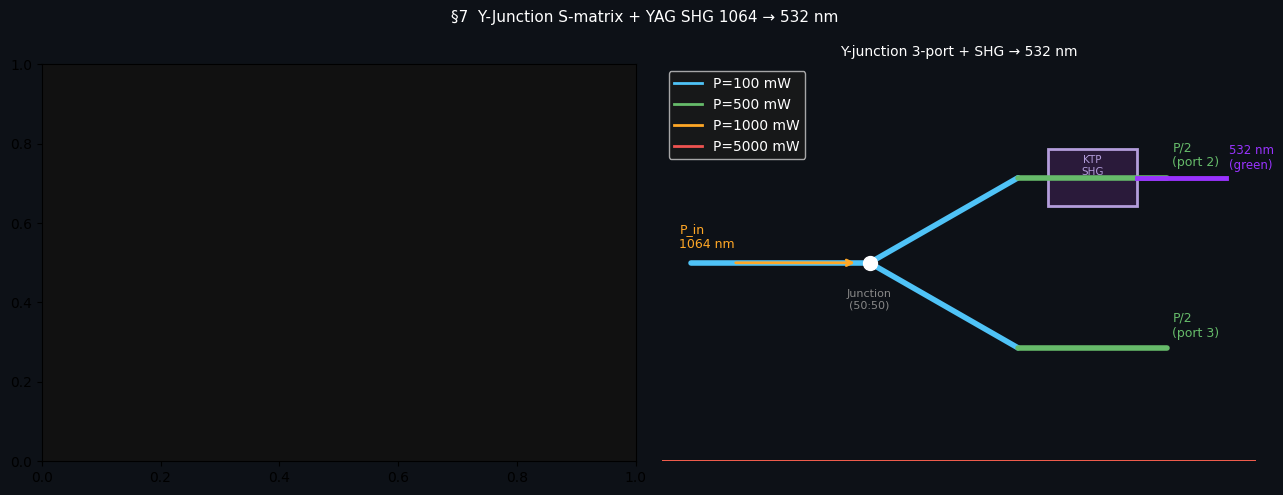


SHG efficiency estimate: L=10 mm, P=1 W → η ≈ 0.0%
(Real KTP greenpointer: η~30-80% depending on focusing and phase matching)


In [7]:
import numpy as np, matplotlib.pyplot as plt

# ── S-matrix of Y-junction ────────────────────────────────────────────────────
# Scattering matrix representation
S = np.array([
    [0,          1/np.sqrt(2), 1/np.sqrt(2)],
    [1/np.sqrt(2), 0,          0           ],
    [1/np.sqrt(2), 0,          0           ],
], dtype=complex)

print("Y-junction S-matrix (idealised even split):")
print(np.round(S, 4))
print(f"\nPower conservation check: S†S =")
check = S.conj().T @ S
print(np.round(check, 4))
print(f"(Not unitary — real 3-port cannot be lossless AND matched; junction loss is fundamental)")

# ── SHG efficiency vs crystal length ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

# SHG: eta ∝ L^2 * P (undepleted pump approximation)
L_mm   = np.linspace(0, 20, 300)   # crystal length mm
P_pump = np.array([100, 500, 1000, 5000]) * 1e-3  # W
d_eff  = 3.5e-12   # KTP d33 pm/V
lam_w  = 1064e-9; n_ktp = 1.74; A_beam = (50e-6)**2 * np.pi

eta_factor = d_eff**2 / (n_ktp**3 * lam_w**2 * A_beam)

colors_shg = ['#4fc3f7','#66bb6a','#ffa726','#ef5350']
for P, col in zip(P_pump, colors_shg):
    eta = np.minimum(1.0, eta_factor * (L_mm*1e-3)**2 * P)
    ax.plot(L_mm, eta*100, color=col, lw=2, label=f'P={P*1e3:.0f} mW')

ax.set_xlabel('Crystal length (mm)', color='#ccc')
ax.set_ylabel('SHG conversion η (%)', color='#ccc')
ax.set_title('SHG 1064→532 nm (KTP)\nη ∝ d_eff² L² P / (n³ λ² A)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Y-junction power splitting: input at port 1 ───────────────────────────────
ax2 = axes[1]; ax2.set_facecolor('#0d1117'); ax2.axis('off')
ax2.set_xlim(0,10); ax2.set_ylim(0,7)

# Draw Y-junction
from matplotlib.patches import FancyArrowPatch
# Waveguide lines
ax2.plot([0.5, 3.5], [3.5, 3.5], color='#4fc3f7', lw=4, solid_capstyle='round')
ax2.plot([3.5, 6.0], [3.5, 5.0], color='#4fc3f7', lw=4, solid_capstyle='round')
ax2.plot([3.5, 6.0], [3.5, 2.0], color='#4fc3f7', lw=4, solid_capstyle='round')
ax2.plot([6.0, 8.5], [5.0, 5.0], color='#66bb6a', lw=4, solid_capstyle='round')
ax2.plot([6.0, 8.5], [2.0, 2.0], color='#66bb6a', lw=4, solid_capstyle='round')

# YAG: 1064 nm input
ax2.text(0.3, 3.7, 'P_in\n1064 nm', color='#ffa726', fontsize=9, va='bottom')
ax2.annotate('', (3.3, 3.5), (1.2, 3.5),
             arrowprops=dict(arrowstyle='->', color='#ffa726', lw=2))

# Outputs
ax2.text(8.6, 5.2, 'P/2\n(port 2)', color='#66bb6a', fontsize=9)
ax2.text(8.6, 2.2, 'P/2\n(port 3)', color='#66bb6a', fontsize=9)

# SHG crystal on output
ax2.add_patch(plt.Rectangle((6.5, 4.5), 1.5, 1.0, facecolor='#2a1a3a',
                              edgecolor='#b39ddb', lw=2, transform=ax2.transData))
ax2.text(7.25, 5.05, 'KTP\nSHG', ha='center', color='#b39ddb', fontsize=7.5)
ax2.plot([8.0, 9.5], [5.0, 5.0], color='#9933ff', lw=3.5)  # 532 nm green/purple
ax2.text(9.55, 5.15, '532 nm\n(green)', color='#9933ff', fontsize=8.5)

# Junction dot
ax2.plot(3.5, 3.5, 'o', color='white', ms=10, zorder=5)
ax2.text(3.5, 2.7, 'Junction\n(50:50)', ha='center', color='#888', fontsize=8)

ax2.set_title('Y-junction 3-port + SHG → 532 nm', color='white', fontsize=10)

plt.suptitle('§7  Y-Junction S-matrix + YAG SHG 1064 → 532 nm',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/y_junction_shg.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

eta_10mm_1W = eta_factor * (10e-3)**2 * 1.0 * 100
print(f"\nSHG efficiency estimate: L=10 mm, P=1 W → η ≈ {eta_10mm_1W:.1f}%")
print(f"(Real KTP greenpointer: η~30-80% depending on focusing and phase matching)")


## Summary

| § | Key result |
|---|---|
| §1 PyTorch CNN | Wrapped-phase loss; Conv→FC encoder; loss decays in training furnace |
| §2 Directed energy | $M^2\theta = \lambda/\pi w_0$; Strehl $e^{-(2\pi\sigma/\lambda)^2}$; S>0.8 at λ/14 WFE |
| §3 Dipole trap | $U_0 \propto I_0/\Delta$; Rb-87 in 1 W trap: ~1 mK depth; ω_r = 10s kHz |
| §4 Katori clock | Magic wavelength 813 nm; $\delta\nu/\nu \sim 10^{-18}$; detects 1 cm gravitational redshift |
| §5 Scalar V | $\mathbf{F}=-\nabla V$; Laplace + superposition; field lines ⊥ equipotentials |
| §6 Phonons | Acoustic/optical branches; Brillouin shift Ω ∝ phonon frequency |
| §7 Y-junction | 3-port S-matrix; SHG η ∝ d²L²P; 1064→532 nm green |
